# Orbital Motion as a Numerical-Modeling Problem

This notebook brings together the main ideas from our study of ordinary differential equations. We will turn Newton's second-order equations into a first-order system, solve that system using three numerical algorithms, and decide whether the results are trustworthy.

The emphasis is not merely on drawing an orbit. A numerical trajectory can look convincing while slowly violating the conservation laws of the physical model. We will therefore compare:

- explicit Euler (RK1),
- Euler–Cromer, and
- classical fourth-order Runge–Kutta (RK4),

using the orbit itself, total energy, and angular momentum as diagnostics. We will use fixed time steps throughout; adaptive step sizing is not required for the lesson.

## From Newton's law to four first-order equations

For a small body orbiting a much more massive body at the origin,

$$
\frac{d^2\mathbf r}{dt^2}=-\frac{GM}{r^3}\mathbf r,
\qquad
r=\sqrt{x^2+y^2}.
$$

Runge–Kutta algorithms solve first-order equations, so we introduce the velocity components $v_x=dx/dt$ and $v_y=dy/dt$. The state vector

$$
\mathbf s=(x,y,v_x,v_y)
$$

then obeys

$$
\frac{d\mathbf s}{dt}=
\begin{pmatrix}
v_x\\
v_y\\
-GMx/r^3\\
-GMy/r^3
\end{pmatrix}.
$$

This conversion is broadly useful: an $n$th-order differential equation can be represented by a system of $n$ first-order equations.

## A convenient system of units

We measure distance in astronomical units (AU), time in years, and mass in solar masses. In these units,

$$GM_\odot \approx 4\pi^2\ \mathrm{AU^3/year^2}.$$

Kepler's third law then becomes

$$T^2=a^3,$$

where $a$ is the semi-major axis in AU and $T$ is the period in years. Thus an orbit with $a=1$ has period $T=1$ year—not $2\pi$ years. The factor $2\pi$ is already contained in $GM=4\pi^2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MU = 4.0 * np.pi**2  # GM_sun in AU^3/year^2

def derivatives(state):
    """Return (vx, vy, ax, ay) for a state (x, y, vx, vy)."""
    x, y, vx, vy = state
    radius = np.hypot(x, y)
    acceleration_factor = -MU / radius**3
    return np.array([vx, vy,
                     acceleration_factor * x,
                     acceleration_factor * y])

def orbital_period(semi_major_axis):
    return np.sqrt(semi_major_axis**3)

def initial_state_at_aphelion(semi_major_axis, eccentricity):
    """State at the farthest point of a counterclockwise orbit."""
    r_aphelion = semi_major_axis * (1.0 + eccentricity)
    speed = np.sqrt(MU * (2.0/r_aphelion - 1.0/semi_major_axis))
    return np.array([r_aphelion, 0.0, 0.0, speed])

## Initial conditions for an ellipse

An ellipse is specified by its semi-major axis $a$ and eccentricity $e$. With the Sun at one focus,

$$r_{\rm peri}=a(1-e),\qquad r_{\rm ap}=a(1+e).$$

We begin at aphelion, on the positive $x$ axis. The required tangential speed follows from the vis-viva equation,

$$v^2=GM\left(\frac{2}{r}-\frac{1}{a}\right).$$

Notice that $v=\sqrt{GM/a}$ is correct only for a circular orbit. For an ellipse, the initial speed must depend on whether the object begins near perihelion or aphelion.

## Three update rules

Explicit Euler advances every component using information from the beginning of the step:

$$\mathbf s_{n+1}=\mathbf s_n+h\,\mathbf f(\mathbf s_n).$$

Euler–Cromer updates the velocity first and then uses the new velocity to update position. It is still first order, but for oscillatory and orbital systems its **symplectic** structure often prevents the unbounded energy drift seen with explicit Euler.

RK4 evaluates four trial slopes and combines them with weights $1,2,2,1$. It is not symplectic, but for sufficiently small $h$ it is usually far more accurate over the time spans considered here.

The methods differ not only in accuracy, but also in cost: Euler and Euler–Cromer require one acceleration evaluation per step, while RK4 requires four derivative evaluations.

In [2]:
def euler_step(state, h):
    return state + h * derivatives(state)

def euler_cromer_step(state, h):
    x, y, vx, vy = state
    ax, ay = derivatives(state)[2:]
    vx_new = vx + h * ax
    vy_new = vy + h * ay
    x_new = x + h * vx_new
    y_new = y + h * vy_new
    return np.array([x_new, y_new, vx_new, vy_new])

def rk4_step(state, h):
    k1 = derivatives(state)
    k2 = derivatives(state + h*k1/2.0)
    k3 = derivatives(state + h*k2/2.0)
    k4 = derivatives(state + h*k3)
    return state + h * (k1 + 2*k2 + 2*k3 + k4) / 6.0

METHODS = {
    "Euler": euler_step,
    "Euler–Cromer": euler_cromer_step,
    "RK4": rk4_step,
}

def integrate_orbit(step_function, initial_state, t_end, h):
    """Integrate through exactly t_end, shortening only the final step."""
    n_steps = int(np.ceil(t_end / h))
    times = np.empty(n_steps + 1)
    states = np.empty((n_steps + 1, 4))
    times[0] = 0.0
    states[0] = initial_state

    for i in range(n_steps):
        step_size = min(h, t_end - times[i])
        states[i + 1] = step_function(states[i], step_size)
        times[i + 1] = times[i] + step_size

    return times, states

## Diagnostics: what should remain constant?

For the ideal two-body problem, two especially useful invariants are the specific mechanical energy

$$
\varepsilon=\frac{v^2}{2}-\frac{GM}{r}
$$

and the $z$ component of the specific angular momentum

$$
\ell_z=xv_y-yv_x.
$$

“Specific” means per unit mass of the orbiting body. The kinetic and potential terms vary around an elliptical orbit, but their sum should remain constant. Angular momentum should also remain constant because gravity is a central force.

Monitoring invariants does not prove that a numerical solution is correct, but failure to conserve them is strong evidence that it is wrong.

In [3]:
def diagnostics(states):
    x, y, vx, vy = states.T
    radius = np.hypot(x, y)
    speed_squared = vx**2 + vy**2
    energy = 0.5 * speed_squared - MU / radius
    angular_momentum = x*vy - y*vx
    return radius, energy, angular_momentum

def relative_change(values):
    return (values - values[0]) / abs(values[0])

# Experiment 1: a circular orbit

For $a=1$ and $e=0$, the exact orbit is a unit circle with a one-year period. We calculate five orbits using the same fixed time step for all three algorithms.

This is a controlled test because we know what should happen: the radius, total energy, and angular momentum should all remain constant, and the object should return to its starting point after each year.

In [4]:
a_circular = 1.0
e_circular = 0.0
n_orbits = 5
h = 0.01  # years
t_end = n_orbits * orbital_period(a_circular)
initial_circular = initial_state_at_aphelion(a_circular, e_circular)

circular_results = {
    name: integrate_orbit(step, initial_circular, t_end, h)
    for name, step in METHODS.items()
}

print(f"Period = {orbital_period(a_circular):.3f} year")
print(f"Integration time = {t_end:.3f} years ({n_orbits} orbits)")
print(f"Nominal step size = {h:.3f} year")

Period = 1.000 year
Integration time = 5.000 years (5 orbits)
Nominal step size = 0.010 year


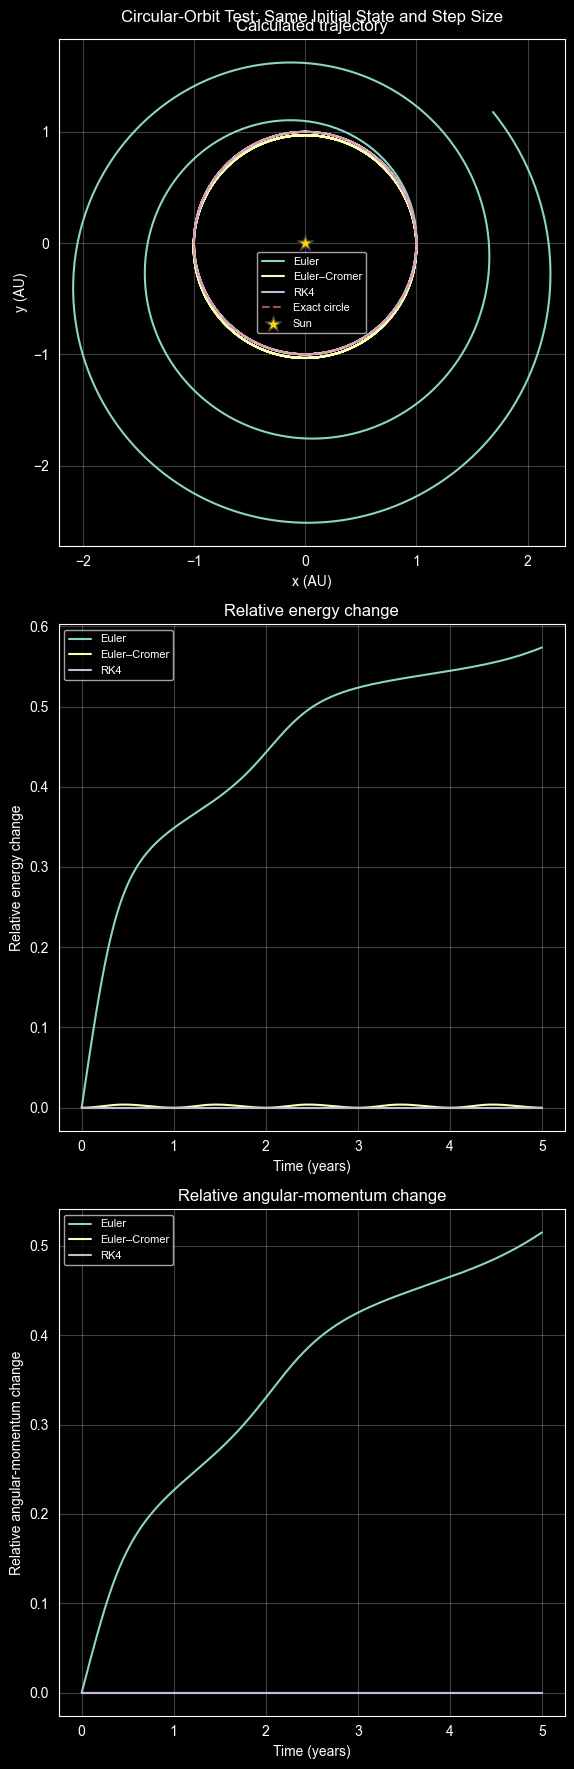

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for name, (times, states) in circular_results.items():
    radius, energy, angular_momentum = diagnostics(states)
    axes[0].plot(states[:, 0], states[:, 1], label=name)
    axes[1].plot(times, relative_change(energy), label=name)
    axes[2].plot(times, relative_change(angular_momentum), label=name)

angle = np.linspace(0, 2*np.pi, 400)
axes[0].plot(np.cos(angle), np.sin(angle), linestyle="--", alpha=0.65,
             label="Exact circle")
axes[0].scatter(0, 0, marker="*", s=140, color="gold", edgecolor="0.25", label="Sun")
axes[0].set(xlabel="x (AU)", ylabel="y (AU)", title="Calculated trajectory")
axes[0].set_aspect("equal", adjustable="box")
axes[1].set(xlabel="Time (years)", ylabel="Relative energy change",
            title="Relative energy change")
axes[2].set(xlabel="Time (years)", ylabel="Relative angular-momentum change",
            title="Relative angular-momentum change")

for ax in axes:
    ax.set_box_aspect(1)
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
axes[2].legend(fontsize=8)
fig.suptitle("Circular-Orbit Test: Same Initial State and Step Size")
fig.tight_layout()
plt.show()

In [6]:
print(f"{'Method':<16}{'final position error':>23}{'max |energy change|':>23}{'max |L change|':>19}")
print("-" * 81)

for name, (times, states) in circular_results.items():
    _, energy, angular_momentum = diagnostics(states)
    position_error = np.linalg.norm(states[-1, :2] - initial_circular[:2])
    max_energy_change = np.max(np.abs(relative_change(energy)))
    max_L_change = np.max(np.abs(relative_change(angular_momentum)))
    print(f"{name:<16}{position_error:>23.3e}{max_energy_change:>23.3e}{max_L_change:>19.3e}")

Method             final position error    max |energy change|     max |L change|
---------------------------------------------------------------------------------
Euler                         1.364e+00              5.736e-01          5.148e-01
Euler–Cromer                  8.783e-02              3.952e-03          8.481e-16
RK4                           3.135e-05              8.553e-07          4.276e-07


### Interpreting the circular-orbit test

- Explicit Euler continually adds energy, so the orbit spirals outward. Its angular momentum also drifts.
- Euler–Cromer produces bounded oscillations rather than secular drift. In fact, its angular momentum is conserved to roundoff for this central-force update, even though its position is not exact.
- RK4 is extremely accurate at this step size, but its small errors are not exactly zero.

The comparison illustrates an important subtlety: **formal order is not the only property of an algorithm**. The structure of the update can matter greatly for long-term dynamics.

# Experiment 2: an eccentric orbit

A circular orbit is forgiving because the orbital speed and distance from the Sun remain constant. In an eccentric orbit the body moves slowly near aphelion and rapidly near perihelion, where the gravitational acceleration is also strongest.

We choose $a=1$ AU and $e=0.6$. The exact ellipse has

$$r_{\rm ap}=1.6\ \mathrm{AU},\qquad r_{\rm peri}=0.4\ \mathrm{AU}.$$

This is demanding enough to reveal time-step sensitivity without the extreme resolution requirements of Halley's comet ($e\approx0.967$).

In [7]:
a_ellipse = 1.0
e_ellipse = 0.6
n_orbits_ellipse = 3
h_ellipse = 0.005
t_end_ellipse = n_orbits_ellipse * orbital_period(a_ellipse)
initial_ellipse = initial_state_at_aphelion(a_ellipse, e_ellipse)

ellipse_results = {
    name: integrate_orbit(step, initial_ellipse, t_end_ellipse, h_ellipse)
    for name, step in METHODS.items()
}

print(f"Aphelion distance  = {a_ellipse*(1+e_ellipse):.3f} AU")
print(f"Perihelion distance = {a_ellipse*(1-e_ellipse):.3f} AU")
print(f"Initial speed       = {initial_ellipse[3]:.3f} AU/year")

Aphelion distance  = 1.600 AU
Perihelion distance = 0.400 AU
Initial speed       = 3.142 AU/year


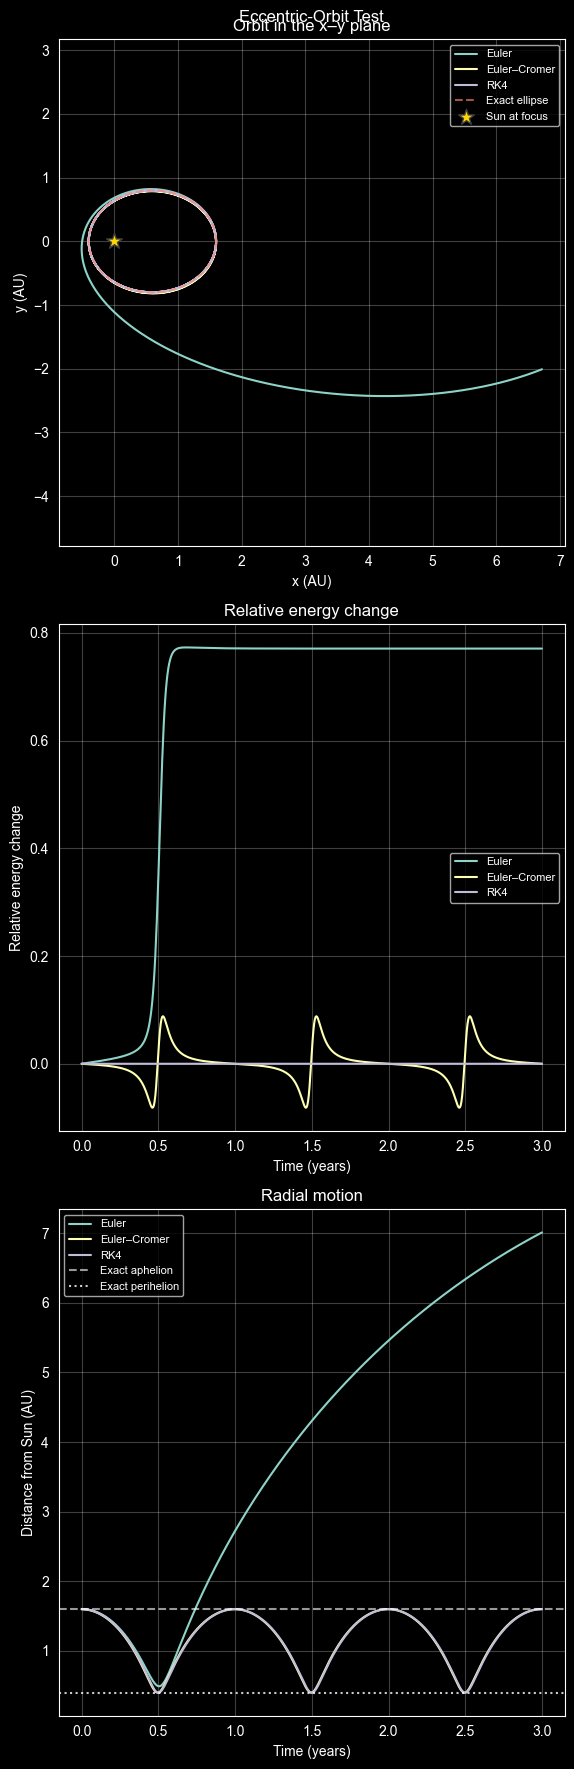

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

theta = np.linspace(0, 2*np.pi, 600)
semi_minor = a_ellipse * np.sqrt(1 - e_ellipse**2)
# The Sun is at the left focus (x=0), so the ellipse center is at x=+a*e.
exact_x = a_ellipse*np.cos(theta) + a_ellipse*e_ellipse
exact_y = semi_minor*np.sin(theta)

for name, (times, states) in ellipse_results.items():
    radius, energy, angular_momentum = diagnostics(states)
    axes[0].plot(states[:, 0], states[:, 1], label=name)
    axes[1].plot(times, relative_change(energy), label=name)
    axes[2].plot(times, radius, label=name)

axes[0].plot(exact_x, exact_y, linestyle="--", alpha=0.65, label="Exact ellipse")
axes[0].scatter(0, 0, marker="*", s=140, color="gold", edgecolor="0.25", label="Sun at focus")
axes[0].set(xlabel="x (AU)", ylabel="y (AU)", title="Orbit in the x–y plane")
axes[0].set_aspect("equal", adjustable="box")
axes[1].set(xlabel="Time (years)", ylabel="Relative energy change",
            title="Relative energy change")
axes[2].axhline(a_ellipse*(1+e_ellipse), linestyle="--", alpha=0.6, label="Exact aphelion")
axes[2].axhline(a_ellipse*(1-e_ellipse), linestyle=":", alpha=0.8, label="Exact perihelion")
axes[2].set(xlabel="Time (years)", ylabel="Distance from Sun (AU)",
            title="Radial motion")

for ax in axes:
    ax.set_box_aspect(1)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle("Eccentric-Orbit Test")
fig.tight_layout()
plt.show()

## Step refinement: separating the model from the calculation

The gravitational model has not changed between methods; only the numerical approximation has. To test whether a result has converged, we repeat one orbit using several values of $h$ and compare the final state with the initial state. Because the true orbit has period one year, the exact state after one orbit equals the initial state.

For a method of order $p$, a general global-error measure should give

$$\text{error}\propto h^p.$$

This is more informative than choosing a single time step and trusting the resulting picture. There is one subtlety: measuring the error after exactly one complete periodic orbit can produce cancellation. Euler–Cromer is formally first order, but this special endpoint test can display an apparent second-order slope because leading phase errors cancel over a full cycle. That is a property of the diagnostic, not a change in the method's formal order.

Method              measured slope     error at smallest h
----------------------------------------------------------
Euler                         0.89               5.137e-01
Euler–Cromer                  2.00               2.179e-05
RK4                           4.09               5.157e-11


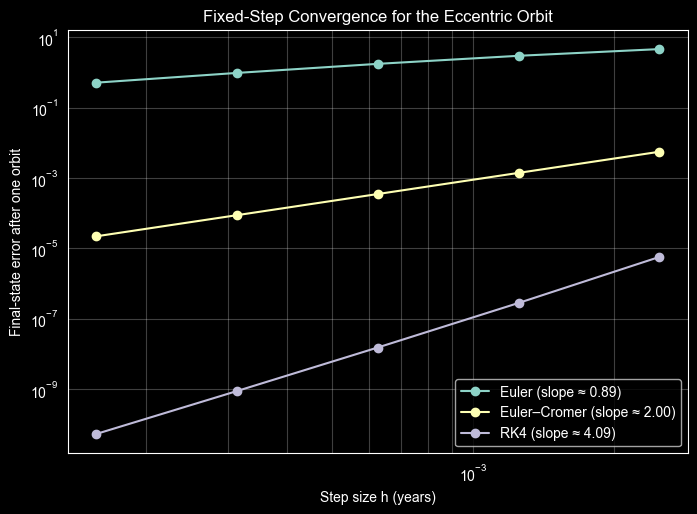

In [9]:
step_sizes = np.array([0.0025, 0.00125, 0.000625, 0.0003125, 0.00015625])
period = orbital_period(a_ellipse)

fig, ax = plt.subplots(figsize=(8, 5.5))
print(f"{'Method':<16}{'measured slope':>18}{'error at smallest h':>24}")
print("-" * 58)

for name, step in METHODS.items():
    errors = []
    for step_size in step_sizes:
        _, states = integrate_orbit(step, initial_ellipse, period, step_size)
        errors.append(np.linalg.norm(states[-1] - initial_ellipse))
    errors = np.asarray(errors)
    slope = np.polyfit(np.log(step_sizes[-3:]), np.log(errors[-3:]), 1)[0]
    print(f"{name:<16}{slope:>18.2f}{errors[-1]:>24.3e}")
    ax.loglog(step_sizes, errors, "o-", label=f"{name} (slope ≈ {slope:.2f})")

ax.set(xlabel="Step size h (years)", ylabel="Final-state error after one orbit",
       title="Fixed-Step Convergence for the Eccentric Orbit")
ax.grid(which="both", alpha=0.25)
ax.legend()
plt.show()

## Modeling lessons from the orbit problem

1. **Translate the mathematics carefully.** A second-order vector equation became four coupled first-order equations.
2. **Units matter.** With years and AU, $GM=4\pi^2$ and a one-AU orbit has a one-year period. Multiplying the requested number of orbits by $2\pi$ would integrate for the wrong duration.
3. **Initial conditions are part of the model.** The circular-speed formula cannot be used unchanged for an elliptical orbit; the vis-viva equation supplies the correct speed.
4. **A plausible plot is not sufficient validation.** Conservation of energy and angular momentum exposes numerical behavior that can be difficult to see in the trajectory.
5. **Accuracy and qualitative behavior are different ideas.** Euler–Cromer is only first order, yet its symplectic structure gives it valuable long-term behavior. RK4 attains much smaller short-term errors for the step sizes used here.
6. **Always perform a step-refinement study.** Agreement between calculations at successively smaller $h$ is evidence that the numerical approximation—not merely the code—has converged.
7. **Difficult orbits require finer temporal resolution.** A highly eccentric orbit such as Halley's comet moves through perihelion very quickly. Adaptive methods can be efficient there, but a sufficiently refined fixed-step calculation already demonstrates the essential modeling issue.

The central question is therefore not “Which method draws an ellipse?” It is “What evidence tells us that the computed trajectory is a reliable solution of the mathematical model?”